
PROBLEM:
Analyze short-term residential real estate market trends in Bengaluru using NumPy for numerical analysis and Pandas for data management, then create a comprehensive visualization dashboard.

TASKS:

1. Create Real Estate Dataset (90 days):
   - Date: Daily dates for 90 consecutive days
   - Price_High: Random floats ₹80–₹180 lakh (highest listed price per day)
   - Price_Low: Random floats ₹40–₹95 lakh (always < Price_High)
   - Avg_Price_per_sqft: Random floats ₹4,000–₹15,000
   - Units_Listed: Random integers 30–220 per day
   - Units_Sold: Random integers 5–120 per day (always ≤ Units_Listed)
   - Home_Loan_Rate: Random floats 8.2–9.8 (%)

   Store in Pandas DataFrame

2. Feature Engineering with Pandas:
   - Add 'Price_Range' column (High - Low)
   - Add 'Price_Avg' column ((High + Low) / 2)
   - Add 'Month' column extracted from Date
   - Add 'High_Demand_Day' boolean column (True if Units_Sold / Units_Listed ≥ 0.6)
   - Add 'Market_Segment' based on avg price and demand:
     * 'Premium_High_Demand': avg > ₹120L and high demand
     * 'Premium_Low_Demand': avg > ₹120L and low demand
     * 'Mid_Market_High_Demand': ₹70L–₹120L and high demand
     * 'Mid_Market_Low_Demand': ₹70L–₹120L and low demand
     * 'Affordable': avg < ₹70L

3. NumPy Statistical Analysis:
   - Convert Price_High, Price_Low, Units_Listed, Units_Sold to 2D NumPy array
   - Calculate correlation matrix between all variables
   - Compute 7-day rolling mean for average prices (use NumPy)
   - Identify price anomalies (days where high price > mean + 2*std)


4. Create Visualization Dashboard:
   - Plot 1: Line plot of daily high/low prices with trend line (Matplotlib)
   - Plot 2: Bar chart of total monthly units sold (Matplotlib)
   - Plot 3: Scatter plot of Avg_Price_per_sqft vs Units_Sold colored by High_Demand_Day (Seaborn)
   - Plot 4: Histogram of price range distribution (Matplotlib)
   - Plot 5: Box plot of average prices by month (Seaborn)
   - Plot 6: Count plot of market segments (Seaborn)
   - Plot 7: Violin plot of units sold by market segment (Seaborn)



In [ ]:
!pip install seaborn

In [5]:
# ============================================
# Bengaluru Real Estate Market Analysis Dashboard
# Using NumPy, Pandas, Matplotlib, and Seaborn
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. CREATE REAL ESTATE DATASET
# --------------------------------------------

np.random.seed(42)

days = 90

# Generate 90 consecutive dates
dates = pd.date_range(start="2025-01-01", periods=days)

# Generate high prices (in lakhs)
price_high = np.random.uniform(80, 180, days)

# Generate low prices ensuring low < high
price_low = np.random.uniform(40, 95, days)

# Fix cases where low accidentally becomes greater
price_low = np.minimum(price_low, price_high - 5)

# Average price per sqft
avg_price_sqft = np.random.uniform(4000, 15000, days)

# Units listed
units_listed = np.random.randint(30, 221, days)

# Units sold ensuring sold <= listed
units_sold = np.array([
    np.random.randint(5, listed + 1)
    for listed in units_listed
])

# Home loan interest rates
home_loan_rate = np.random.uniform(8.2, 9.8, days)

# Create DataFrame
df = pd.DataFrame({
    "Date": dates,
    "Price_High": price_high,
    "Price_Low": price_low,
    "Avg_Price_per_sqft": avg_price_sqft,
    "Units_Listed": units_listed,
    "Units_Sold": units_sold,
    "Home_Loan_Rate": home_loan_rate
})

print("\n===== INITIAL DATASET =====")
print(df.head())




===== INITIAL DATASET =====
        Date  Price_High  Price_Low  Avg_Price_per_sqft  Units_Listed  \
0 2025-01-01  117.454012  46.577684         7751.729862            55   
1 2025-01-02  175.071431  79.228463         5248.208734           128   
2 2025-01-03  153.199394  81.843178        14171.629801            79   
3 2025-01-04  139.865848  70.870246        13650.732887           182   
4 2025-01-05   95.601864  82.403195         6837.357905           181   

   Units_Sold  Home_Loan_Rate  
0          20        9.587387  
1          65        9.098987  
2          68        8.581755  
3          73        9.287752  
4          26        9.383854  


In [6]:

# --------------------------------------------
# 2. FEATURE ENGINEERING
# --------------------------------------------

# Price Range
df["Price_Range"] = df["Price_High"] - df["Price_Low"]

# Average Property Price
df["Price_Avg"] = (df["Price_High"] + df["Price_Low"]) / 2

# Month Extraction
df["Month"] = df["Date"].dt.month_name()

# High Demand Day
df["High_Demand_Day"] = (
    df["Units_Sold"] / df["Units_Listed"]
) >= 0.6


# Market Segment Function
def classify_market(row):

    avg_price = row["Price_Avg"]
    high_demand = row["High_Demand_Day"]

    if avg_price > 120:
        if high_demand:
            return "Premium_High_Demand"
        else:
            return "Premium_Low_Demand"

    elif 70 <= avg_price <= 120:
        if high_demand:
            return "Mid_Market_High_Demand"
        else:
            return "Mid_Market_Low_Demand"

    else:
        return "Affordable"


df["Market_Segment"] = df.apply(classify_market, axis=1)

print("\n===== FEATURE ENGINEERED DATA =====")
print(df.head())




===== FEATURE ENGINEERED DATA =====
        Date  Price_High  Price_Low  Avg_Price_per_sqft  Units_Listed  \
0 2025-01-01  117.454012  46.577684         7751.729862            55   
1 2025-01-02  175.071431  79.228463         5248.208734           128   
2 2025-01-03  153.199394  81.843178        14171.629801            79   
3 2025-01-04  139.865848  70.870246        13650.732887           182   
4 2025-01-05   95.601864  82.403195         6837.357905           181   

   Units_Sold  Home_Loan_Rate  Price_Range   Price_Avg    Month  \
0          20        9.587387    70.876328   82.015848  January   
1          65        9.098987    95.842967  127.149947  January   
2          68        8.581755    71.356217  117.521286  January   
3          73        9.287752    68.995603  105.368047  January   
4          26        9.383854    13.198669   89.002529  January   

   High_Demand_Day          Market_Segment  
0            False   Mid_Market_Low_Demand  
1            False      Premium

In [7]:

# --------------------------------------------
# 3. NUMPY STATISTICAL ANALYSIS
# --------------------------------------------

# Convert selected columns to NumPy 2D array
real_estate_array = df[
    ["Price_High", "Price_Low",
     "Units_Listed", "Units_Sold"]
].to_numpy()

print("\n===== NUMPY ARRAY =====")
print(real_estate_array[:5])

# Correlation Matrix
correlation_matrix = np.corrcoef(real_estate_array.T)

print("\n===== CORRELATION MATRIX =====")
print(correlation_matrix)
'''
|             | A(Size)   | B(Bedrooms) | C(Price)  | D(Age)    |
| ----------- | --------- | ----------- | --------- | --------- |
| A(Size)     | corr(A,A) | corr(A,B)   | corr(A,C) | corr(A,D) |
| B(Bedrooms) | corr(B,A) | corr(B,B)   | corr(B,C) | corr(B,D) |
| C(Price)    | corr(C,A) | corr(C,B)   | corr(C,C) | corr(C,D) |
| D(Age)      | corr(D,A) | corr(D,B)   | corr(D,C) | corr(D,D) |
'''

# 7-Day Rolling Mean using NumPy
price_avg_array = df["Price_Avg"].to_numpy()
print(f"\nLength of price_avg_array: {len(price_avg_array)}")

rolling_mean_7 = np.convolve(
    price_avg_array,
    np.ones(7) / 7,
    mode='valid'
)

print("\n===== 7-DAY ROLLING MEAN =====")
print(rolling_mean_7[:10])

# Price Anomaly Detection
high_mean = np.mean(df["Price_High"])
high_std = np.std(df["Price_High"])

threshold = high_mean + (2 * high_std)

anomalies = df[df["Price_High"] > threshold][:10]

print("\n===== PRICE ANOMALIES =====")
print(anomalies[["Date", "Price_High"]])




===== NUMPY ARRAY =====
[[117.45401188  46.57768353  55.          20.        ]
 [175.07143064  79.2284633  128.          65.        ]
 [153.19939418  81.84317767  79.          68.        ]
 [139.86584842  70.87024587 182.          73.        ]
 [ 95.60186404  82.4031949  181.          26.        ]]

===== CORRELATION MATRIX =====
[[ 1.         -0.02402382 -0.02778628  0.04293193]
 [-0.02402382  1.          0.23725636  0.03623813]
 [-0.02778628  0.23725636  1.          0.46802161]
 [ 0.04293193  0.03623813  0.46802161  1.        ]]

Length of price_avg_array: 90

===== 7-DAY ROLLING MEAN =====
[ 97.10229936 101.82377616  96.62446611  93.88865999  87.6780143
  92.96290708  97.08973802  98.13592604  95.13351763  93.02937266]

===== PRICE ANOMALIES =====
Empty DataFrame
Columns: [Date, Price_High]
Index: []


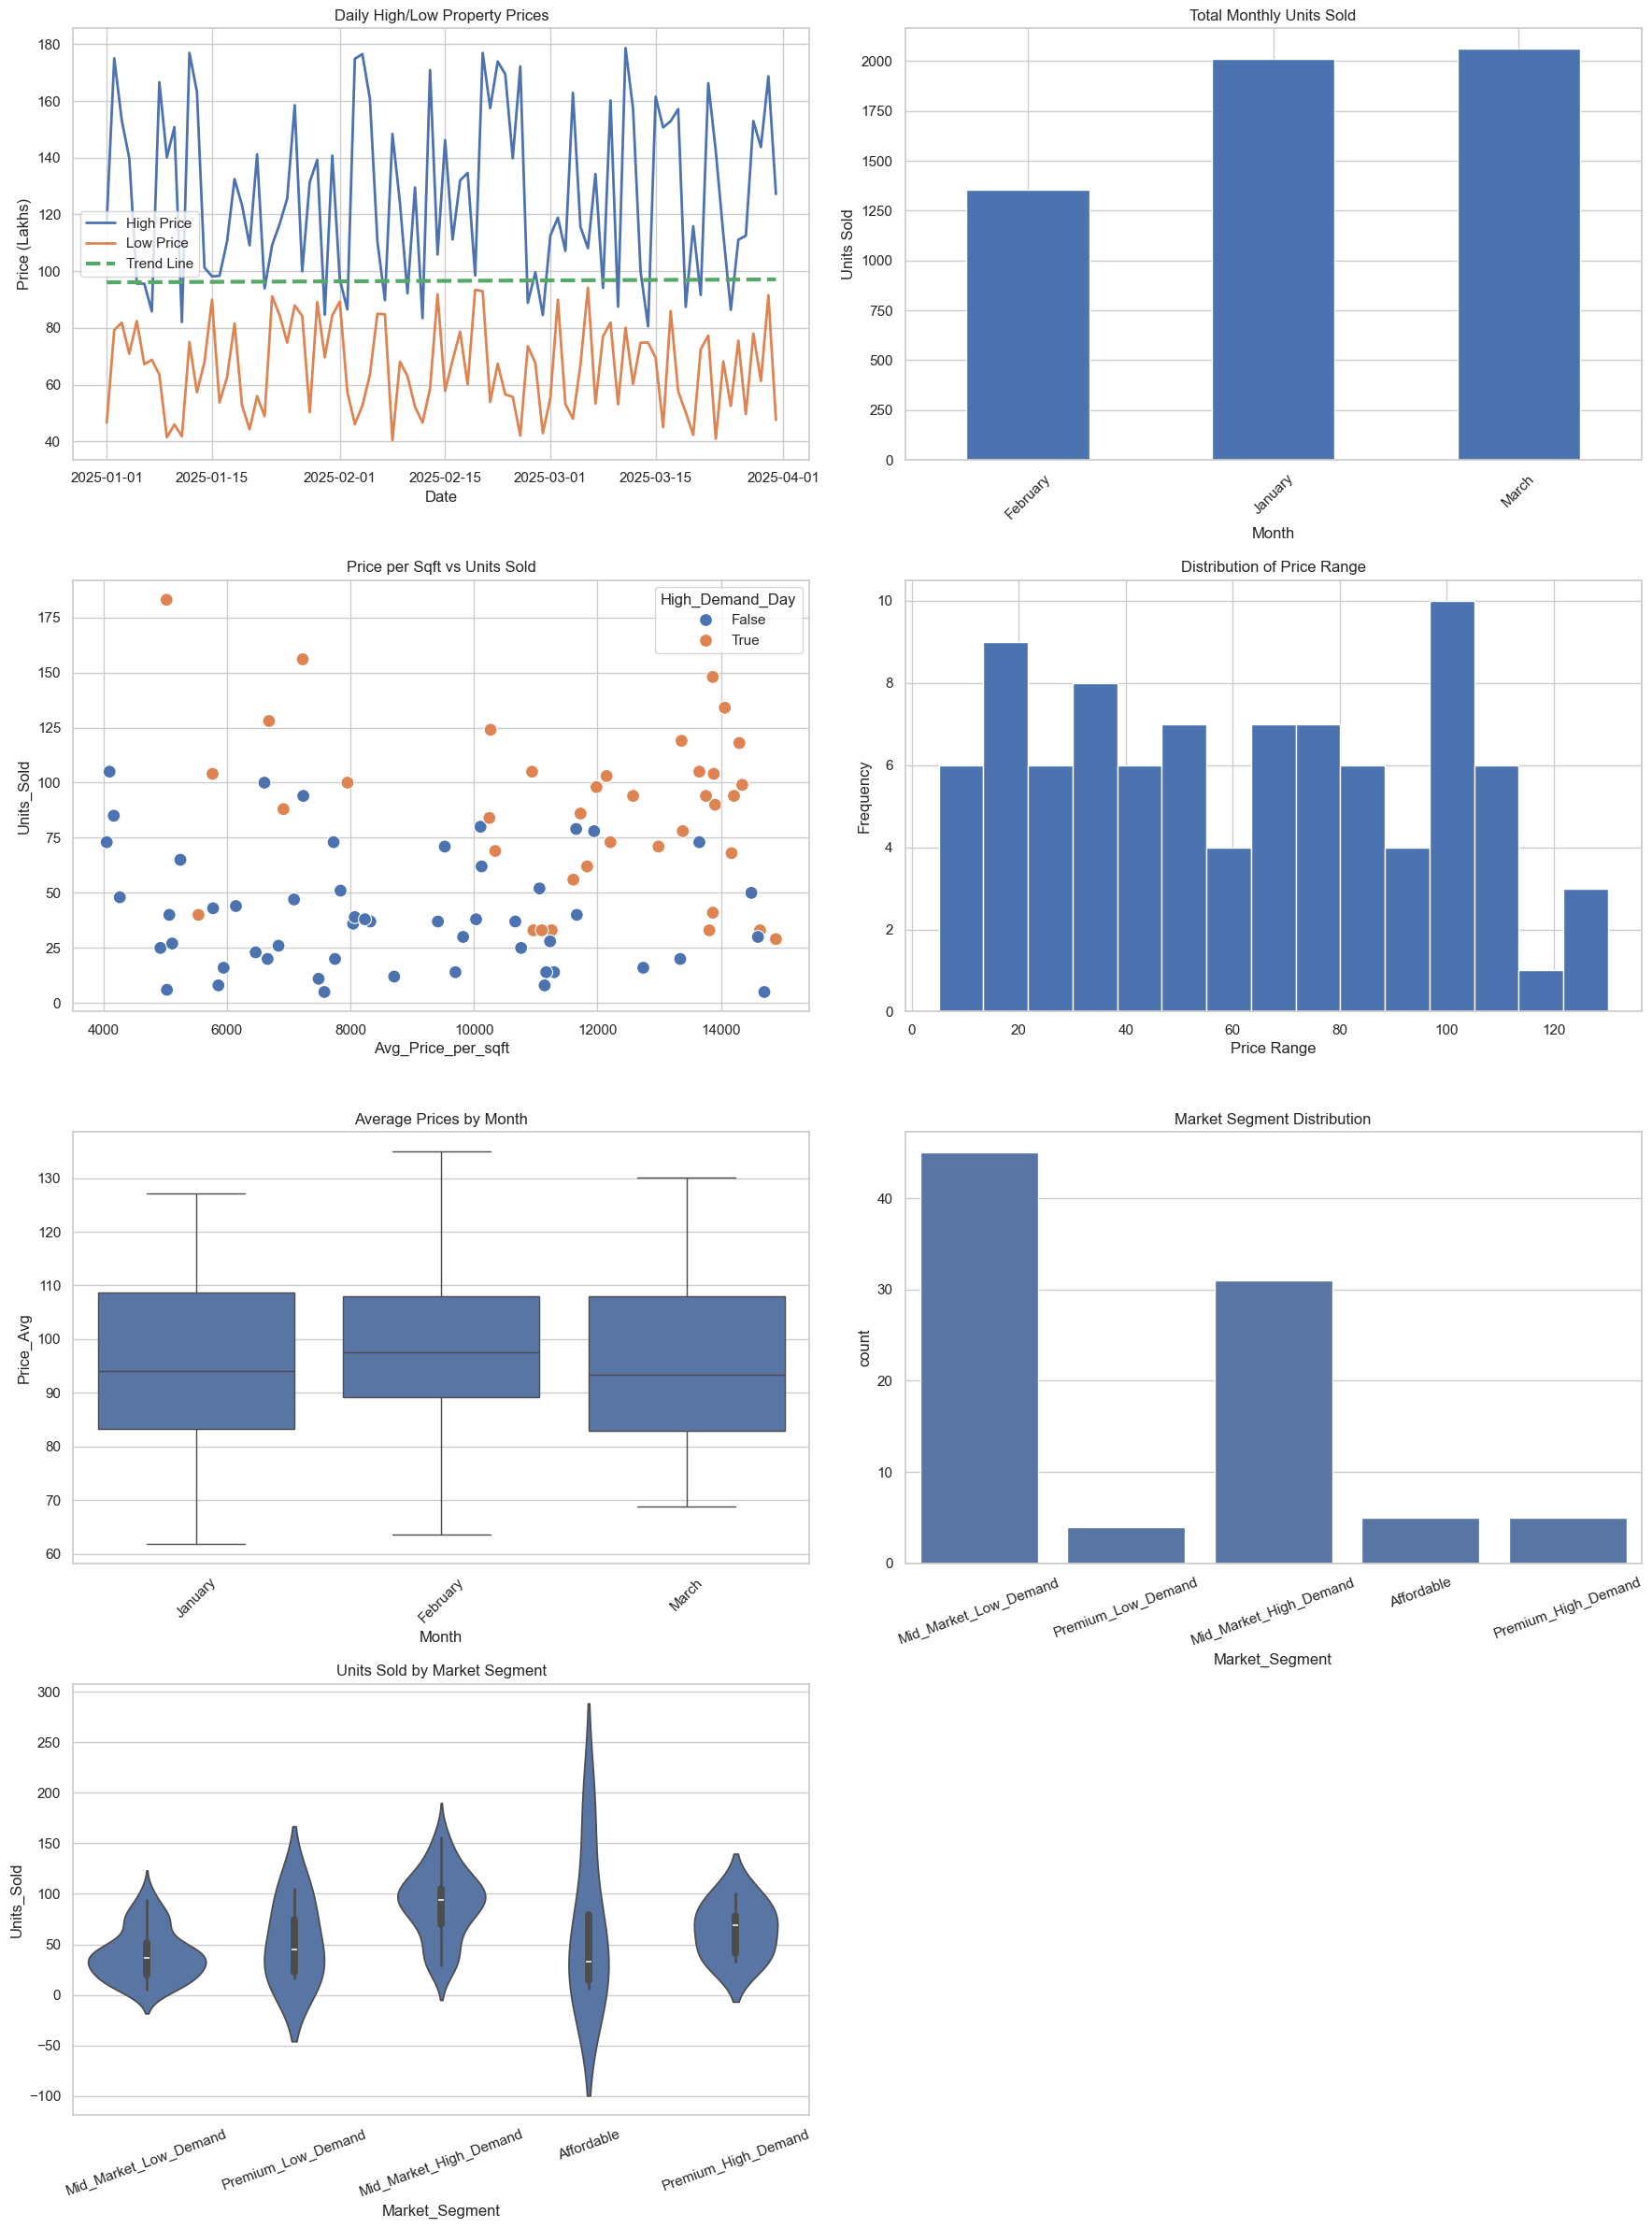


===== SUMMARY STATISTICS =====
                      Date  Price_High  Price_Low  Avg_Price_per_sqft  \
count                   90   90.000000  90.000000           90.000000   
mean   2025-02-14 12:00:00  127.238695  65.922789         9919.295202   
min    2025-01-01 00:00:00   80.552212  40.382367         4055.677422   
25%    2025-01-23 06:00:00   99.666607  52.705441         7123.749562   
50%    2025-02-14 12:00:00  124.811124  67.039330        10308.307801   
75%    2025-03-08 18:00:00  153.139700  79.087858        12701.851005   
max    2025-03-31 00:00:00  178.688694  94.210775        14890.592351   
std                    NaN   30.096549  15.838688         3246.243481   

       Units_Listed  Units_Sold  Home_Loan_Rate  Price_Range   Price_Avg  
count     90.000000   90.000000       90.000000    90.000000   90.000000  
mean     122.722222   60.311111        9.062076    61.315906   96.580742  
min       30.000000    5.000000        8.269441     5.000000   61.893527  
25%       

In [21]:

# --------------------------------------------
# 4. VISUALIZATION DASHBOARD
# --------------------------------------------

sns.set(style="whitegrid")

plt.figure(figsize=(18, 24))


# --------------------------------------------
# PLOT 1: HIGH / LOW PRICE TREND
# --------------------------------------------

plt.subplot(4, 2, 1)

plt.plot(df["Date"], df["Price_High"],
         label="High Price", linewidth=2)

plt.plot(df["Date"], df["Price_Low"],
         label="Low Price", linewidth=2)

# Trend line for average price
z = np.polyfit(
    np.arange(len(df)),
    df["Price_Avg"],
    1
)

p = np.poly1d(z)

plt.plot(
    df["Date"],
    p(np.arange(len(df))),
    linestyle='--',
    linewidth=3,
    label="Trend Line"
)

plt.title("Daily High/Low Property Prices")
plt.xlabel("Date")
plt.ylabel("Price (Lakhs)")
plt.legend()


# --------------------------------------------
# PLOT 2: MONTHLY UNITS SOLD
# --------------------------------------------

plt.subplot(4, 2, 2)

monthly_sales = df.groupby("Month")["Units_Sold"].sum()

monthly_sales.plot(kind='bar')

plt.title("Total Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)


# --------------------------------------------
# PLOT 3: SCATTER PLOT
# --------------------------------------------

plt.subplot(4, 2, 3)

sns.scatterplot(
    data=df,
    x="Avg_Price_per_sqft",
    y="Units_Sold",
    hue="High_Demand_Day",
    s=100
)

plt.title("Price per Sqft vs Units Sold")


# --------------------------------------------
# PLOT 4: HISTOGRAM OF PRICE RANGE
# --------------------------------------------

plt.subplot(4, 2, 4)

plt.hist(df["Price_Range"], bins=15)

plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Frequency")


# --------------------------------------------
# PLOT 5: BOXPLOT OF AVG PRICES BY MONTH
# --------------------------------------------

plt.subplot(4, 2, 5)

sns.boxplot(
    data=df,
    x="Month",
    y="Price_Avg"
)

plt.title("Average Prices by Month")
plt.xticks(rotation=45)


# --------------------------------------------
# PLOT 6: MARKET SEGMENT COUNT
# --------------------------------------------

plt.subplot(4, 2, 6)

sns.countplot(
    data=df,
    x="Market_Segment"
)

plt.title("Market Segment Distribution")
plt.xticks(rotation=20)


# --------------------------------------------
# PLOT 7: VIOLIN PLOT
# --------------------------------------------

plt.subplot(4, 2, 7)

sns.violinplot(
    data=df,
    x="Market_Segment",
    y="Units_Sold"
)

plt.title("Units Sold by Market Segment")
plt.xticks(rotation=20)


# --------------------------------------------
# FINAL LAYOUT
# --------------------------------------------

plt.tight_layout()
plt.show()


# --------------------------------------------
# OPTIONAL SUMMARY STATISTICS

# --------------------------------------------

print("\n===== SUMMARY STATISTICS =====")
print(df.describe())


